# 1.Domain Analysis

In [13]:
## predict salary using experience

# 2.Basic Checks

In [14]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [15]:
## import data 

In [16]:
df=pd.read_csv(r"C:\Users\bhanu\Downloads\salary_data.csv")

In [17]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [18]:
df.tail()

,YearsExperience,Salary
25,9.0,105582
26,9.5,116969
27,9.6,112635
28,10.3,122391
29,10.5,121872


In [19]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


## 3.Exploratory Data Analysis

In [21]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [22]:
##step:1 univariate analysis

<Axes: xlabel='YearsExperience', ylabel='Count'>

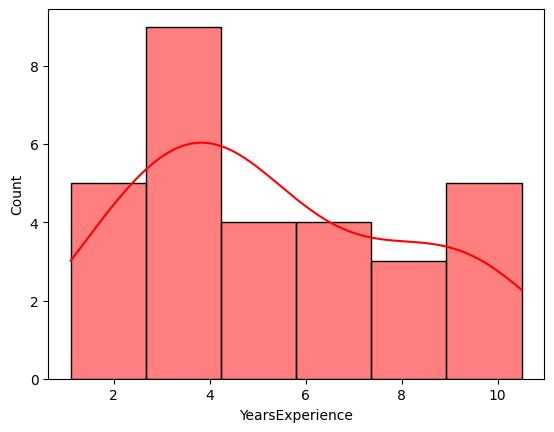

In [23]:
sns.histplot(x=df.YearsExperience,kde=True,color='red')

<Axes: xlabel='YearsExperience', ylabel='Salary'>

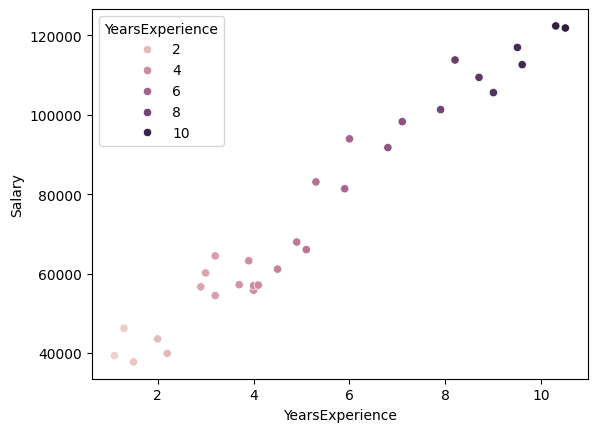

In [24]:
##performing bivariate analysis
sns.scatterplot(x='YearsExperience',y='Salary',hue='YearsExperience',data=df)

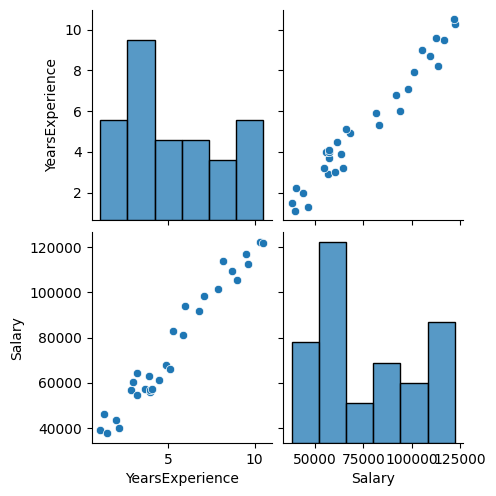

In [25]:
##performing multivarrriate
sns.pairplot(df)

## 4.Data preprocessing and future engineering 

In [26]:
#checking null values
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [49]:
#checking suplicated values
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='YearsExperience'>

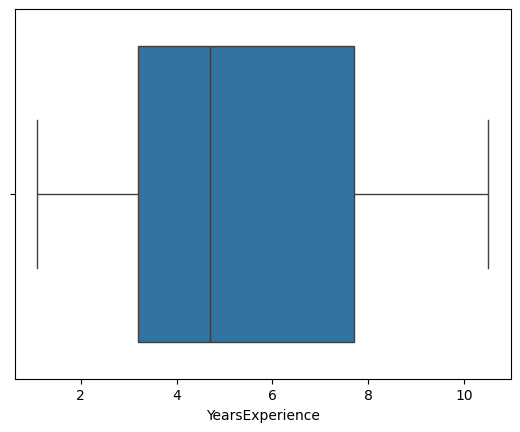

In [50]:
#checking outliers 
sns.boxplot(x='YearsExperience',data=df)

<Axes: xlabel='Salary'>

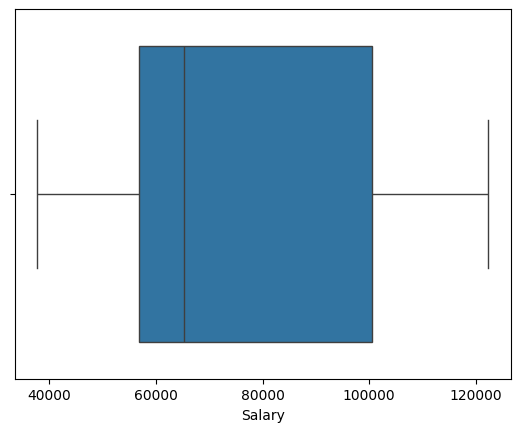

In [51]:
sns.boxplot(x='Salary',data=df)

## 5.Feature Selection

<Axes: >

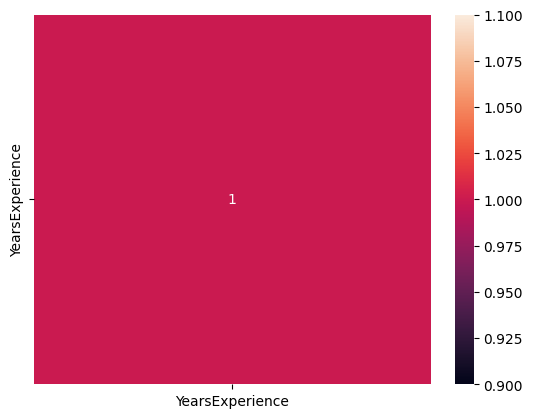

In [52]:
## Step 2 Checking the correlation
sns.heatmap(df.drop('Salary',axis=1).corr(),annot=True)

In [53]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [54]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


## 6.Model Building 

In [55]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [56]:
#assigning Dependent And Independent variable
X=df[['YearsExperience']]
y=df.Salary

In [60]:
#Training and Testing data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [61]:
y_train

28    122391
24    109431
12     56957
0      39343
4      39891
16     66029
5      56642
13     57081
11     55794
22    101302
1      46205
2      37731
25    105582
3      43525
21     98273
26    116969
18     81363
29    121872
20     91738
7      54445
10     63218
14     61111
19     93940
6      60150
Name: Salary, dtype: int64

In [62]:
y_test

27    112635
15     67938
23    113812
17     83088
8      64445
9      57189
Name: Salary, dtype: int64

In [63]:
from sklearn.linear_model import LinearRegression
LR=LinearRegression()
LR.fit(X_train,y_train)
y_predict=LR.predict(X_test)

In [64]:
y_test

27    112635
15     67938
23    113812
17     83088
8      64445
9      57189
Name: Salary, dtype: int64

In [65]:
y_predict

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

In [66]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
r2score=r2_score(y_test,y_predict)

In [67]:
r2score

0.9024461774180497

In [68]:
X_test.shape

(6, 1)

In [69]:
import math 
print(mean_squared_error(y_test,y_predict))
print(math.sqrt(mean_squared_error(y_test,y_predict)))

49830096.85590839
7059.04362190151


In [70]:
print(mean_absolute_error(y_test,y_predict))

6286.453830757749


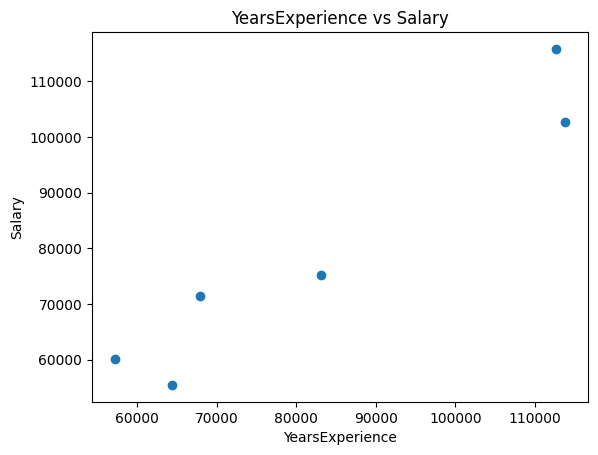

In [71]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_predict)
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.title("YearsExperience vs Salary")
plt.show()


In [80]:
#Model building for Support Vector Regressor
import warnings
warnings.filterwarnings("ignore")

In [77]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
model=SVR()
#grid hyperameters
param_grid={
    'C':[0.1,1,10],
    'kernel':['linear','rbf','poly','sigmoid'],
    'gamma':['auto','scale']
}

#grid search with 5 fold cross validation
grid=GridSearchCV(model,param_grid,cv=5,scoring='accuracy',verbose=1,n_jobs=-1)

#Train The Model
grid.fit(X_train,y_train)


Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['auto', 'scale'], 'kernel': ['linear', 'rbf', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;-

In [79]:
y_test_pred=grid.predict(X_test)
y_train_pred=grid.predict(X_train)

In [82]:
#Evaluation
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
r2_score(y_test,y_test_pred)

-0.8631239189405755

In [113]:
#model Building for svr
sr=SVR(kernel='poly',C=10,gamma=10,epsilon=10)
sr.fit(X_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",10
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",10
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [114]:
#Prediction
y_trai_pred=sr.predict(X_train)
y_tes_pred=sr.predict(X_test)

In [115]:
#Evaluation
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
r2_score(y_test,y_tes_pred)

0.6803268806864152